In [1]:
# ==================================================
# DATASET CREATOR FOR RETAILPULSE (Google Colab Auto-Setup)
# ==================================================

import csv
import random
from datetime import datetime, timedelta

random.seed(42)

catalog = [
    {"Category": "Technology", "Sub_Category": "Accessories", "Product": "Wireless Mouse", "BasePrice": 800, "Cost": 400},
    {"Category": "Technology", "Sub_Category": "Accessories", "Product": "Mechanical Keyboard", "BasePrice": 3500, "Cost": 2000},
    {"Category": "Technology", "Sub_Category": "Accessories", "Product": "USB-C Multi-Port Hub", "BasePrice": 1800, "Cost": 900},
    {"Category": "Technology", "Sub_Category": "Phones", "Product": "Smartphone Pro Max", "BasePrice": 45000, "Cost": 36000},
    {"Category": "Technology", "Sub_Category": "Phones", "Product": "Bluetooth Wireless Earbuds", "BasePrice": 2500, "Cost": 1200},
    {"Category": "Technology", "Sub_Category": "Monitors", "Product": "27-inch 4K Monitor", "BasePrice": 22000, "Cost": 17000},
    {"Category": "Furniture", "Sub_Category": "Chairs", "Product": "Ergonomic Office Chair", "BasePrice": 8500, "Cost": 6000},
    {"Category": "Furniture", "Sub_Category": "Chairs", "Product": "Mesh Executive Chair", "BasePrice": 12000, "Cost": 9500},
    {"Category": "Furniture", "Sub_Category": "Tables", "Product": "Adjustable Standing Desk", "BasePrice": 18000, "Cost": 14000},
    {"Category": "Furniture", "Sub_Category": "Tables", "Product": "Wooden Conference Table", "BasePrice": 25000, "Cost": 21000},
    {"Category": "Furniture", "Sub_Category": "Bookcases", "Product": "5-Tier Wooden Bookshelf", "BasePrice": 6500, "Cost": 5200},
    {"Category": "Office Supplies", "Sub_Category": "Paper", "Product": "A4 Multipurpose Copy Paper (Pack of 5)", "BasePrice": 1200, "Cost": 700},
    {"Category": "Office Supplies", "Sub_Category": "Paper", "Product": "Premium Hardbound Notebook", "BasePrice": 450, "Cost": 180},
    {"Category": "Office Supplies", "Sub_Category": "Storage", "Product": "Heavy Duty Arch File Box", "BasePrice": 650, "Cost": 350},
    {"Category": "Office Supplies", "Sub_Category": "Art", "Product": "Highlighter & Marker Set", "BasePrice": 350, "Cost": 150},
    {"Category": "Office Supplies", "Sub_Category": "Binders", "Product": "Heavy-Duty Ring Binder", "BasePrice": 280, "Cost": 120},
    {"Category": "Apparel", "Sub_Category": "Corporate Wear", "Product": "Cotton Formal Shirt", "BasePrice": 1500, "Cost": 750},
    {"Category": "Apparel", "Sub_Category": "Corporate Wear", "Product": "Tailored Blazer", "BasePrice": 4800, "Cost": 2600},
    {"Category": "Apparel", "Sub_Category": "Footwear", "Product": "Leather Oxford Shoes", "BasePrice": 3200, "Cost": 1700}
]

names = ["Rahul Sharma", "Priya Patel", "Amit Kumar", "Ananya Roy", "Vikas Singh", "Sneha Reddy", "Rohan Mehta", "Neha Gupta", "Karan Joshi", "Pooja Verma", "Suresh Nair", "Deepak Rao", "Kavita Das", "Manish Malhotra", "Divya Agarwal"]

customers = [{"Customer_ID": f"CUST-{1000 + i}", "Customer_Name": f"{random.choice(names)} {i}"} for i in range(1, 251)]
region_cities = {"North": ["Delhi", "Lucknow", "Jaipur"], "South": ["Bangalore", "Chennai", "Hyderabad"], "West": ["Mumbai", "Pune", "Ahmedabad"], "East": ["Kolkata", "Bhubaneswar", "Patna"], "Central": ["Bhopal", "Indore", "Nagpur"]}
regions = list(region_cities.keys())
payment_modes = ["UPI", "Credit Card", "Debit Card", "Net Banking", "Cash on Delivery"]
discounts = [0.0, 0.0, 0.0, 0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]

start_date, end_date = datetime(2024, 1, 1), datetime(2025, 12, 31)
total_days = (end_date - start_date).days

headers = ["Order_ID", "Order_Date", "Customer_ID", "Customer_Name", "Category", "Sub_Category", "Product", "Region", "City", "Quantity", "Sales", "Discount", "Profit", "Payment_Mode"]
rows = []

for i in range(1, 6501):
    order_id = f"ORD-{10000 + i}"
    order_date = start_date + timedelta(days=random.randint(0, total_days))
    if order_date.month in [10, 11, 12] and random.random() < 0.35:
        order_date = datetime(order_date.year, random.choice([10, 11, 12]), random.randint(1, 28))
    cust, prod = random.choice(customers), random.choice(catalog)
    region = random.choice(regions)
    city = random.choice(region_cities[region])
    quantity = random.choices([1, 2, 3, 4, 5, 8, 10], weights=[45, 25, 15, 8, 4, 2, 1])[0]
    discount = random.choice(discounts)
    sales = round(prod["BasePrice"] * quantity * (1 - discount), 2)
    profit = round(sales - (prod["Cost"] * quantity), 2)
    c_name = cust["Customer_Name"] if i not in [100, 250, 400, 750, 1200, 1800, 2500, 3200, 4500, 5800] else ""
    rows.append([order_id, order_date.strftime("%Y-%m-%d"), cust["Customer_ID"], c_name, prod["Category"], prod["Sub_Category"], prod["Product"], region, city, quantity, sales, discount, profit, random.choice(payment_modes)])

for d in range(5):
    rows.append(rows[d].copy())

with open("retail_sales.csv", mode="w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(headers)
    writer.writerows(rows)

print("`retail_sales.csv` created successfully in Google Colab session storage!")


`retail_sales.csv` created successfully in Google Colab session storage!


# RETAILPULSE — Sales Performance & Customer Insights Analytics System
**Domain:** Business Data Analytics  
**Primary Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab  
**Project Goal:** Transform raw retail transaction data into actionable business intelligence insights.


## 01. Business Understanding

### Purpose of Analysis
A growing retail company has accumulated thousands of sales transactions but struggles to make data-driven decisions. The objective of RETAILPULSE is to audit, clean, analyze, and visualize raw sales transaction data to answer critical operational and financial questions:
1. Which products and categories drive revenue versus actual profit?
2. How do different regions perform?
3. When do sales peak (seasonal and time trends)?
4. Who are the most valuable customers?
5. How do discounts impact net profitability?

### Target Audience / Stakeholders
- **Sales Managers:** To identify top-performing products and sales seasonality.
- **Business & Operations Managers:** To optimize regional distribution and address unprofitable product categories.
- **Marketing Team:** To design targeted customer retention campaigns and optimize discount strategies.

### Decision Support Examples
- **Pricing Strategy:** Adjusting discount tiers to avoid eroding profit margins.
- **Inventory & Supply Chain:** Stocking up high-demand categories prior to peak months.
- **Customer Relationship Management (CRM):** Rewarding and retaining top revenue-contributing customers.

> *Note: Data analysis is not merely writing Python code; it is using empirical data to answer business questions and guide strategic decisions.*


In [2]:
# ==================================================
# STEP 1: Environment & Library Setup
# ==================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure chart appearance
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [3]:
# ==================================================
# STEP 3: Load Dataset
# ==================================================

file_path = "retail_sales.csv"  # Ensure this matches your uploaded dataset filename

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print(f"File '{file_path}' not found in Colab files!")
    print("Please upload your file via the folder icon 📁 on the left panel.")

# Display basic information
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")
print("\nFirst 5 Rows:")
display(df.head())


Dataset loaded successfully!
Total Rows: 6,505
Total Columns: 14

First 5 Rows:


,Order_ID,Order_Date,Customer_ID,Customer_Name,Category,Sub_Category,Product,Region,City,Quantity,Sales,Discount,Profit,Payment_Mode
0,ORD-10001,2025-08-03,CUST-1243,Sneha Reddy 243,Technology,Accessories,USB-C Multi-Port Hub,North,Jaipur,2,3600.0,0.00,1800.0,Cash on Delivery
1,ORD-10002,2024-05-08,CUST-1033,Ananya Roy 33,Office Supplies,Binders,Heavy-Duty Ring Binder,Central,Bhopal,1,140.0,0.50,20.0,Net Banking
2,ORD-10003,2024-08-04,CUST-1238,Sneha Reddy 238,Apparel,Corporate Wear,Tailored Blazer,South,Hyderabad,1,4080.0,0.15,1480.0,Net Banking
3,ORD-10004,2025-06-13,CUST-1116,Rohan Mehta 116,Technology,Phones,Smartphone Pro Max,South,Bangalore,1,45000.0,0.00,9000.0,Cash on Delivery
4,ORD-10005,2025-07-21,CUST-1059,Vikas Singh 59,Apparel,Footwear,Leather Oxford Shoes,South,Bangalore,1,3200.0,0.00,1500.0,Credit Card


### 02.1 Initial Data Audit

We now perform the mandatory PDF data audit to inspect shape, column types, statistical distributions, missing values, and duplicate rows.


In [4]:
# ==================================================
# STEP 4: Initial Data Audit
# ==================================================

print("=== 1. DATASET SHAPE ===")
print(f"Total Rows   : {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}\n")

print("=== 2. COLUMN NAMES ===")
print(df.columns.tolist(), "\n")

print("=== 3. DATA TYPES ===")
print(df.dtypes, "\n")

print("=== 4. DATASET INFO ===")
df.info()

print("\n=== 5. MISSING VALUES PER COLUMN ===")
print(df.isnull().sum())

print("\n=== 6. DUPLICATE RECORDS ===")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

print("\n=== 7. NUMERICAL STATISTICAL SUMMARY ===")
display(df.describe())


=== 1. DATASET SHAPE ===
Total Rows   : 6,505
Total Columns: 14

=== 2. COLUMN NAMES ===
['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Category', 'Sub_Category', 'Product', 'Region', 'City', 'Quantity', 'Sales', 'Discount', 'Profit', 'Payment_Mode'] 

=== 3. DATA TYPES ===
Order_ID          object
Order_Date        object
Customer_ID       object
Customer_Name     object
Category          object
Sub_Category      object
Product           object
Region            object
City              object
Quantity           int64
Sales            float64
Discount         float64
Profit           float64
Payment_Mode      object
dtype: object 

=== 4. DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6505 entries, 0 to 6504
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       6505 non-null   object 
 1   Order_Date     6505 non-null   object 
 2   Customer_ID    6505 non-null   obj

,Quantity,Sales,Discount,Profit
count,6505.000000,6505.000000,6505.000000,6505.000000
mean,2.183705,15105.157494,0.167986,1401.753958
std,1.634568,28570.804849,0.168822,6529.549798
min,1.000000,140.000000,0.000000,-72000.000000
25%,1.000000,1300.000000,0.000000,160.000000
50%,2.000000,4500.000000,0.100000,750.000000
75%,3.000000,17000.000000,0.300000,2500.000000
max,10.000000,450000.000000,0.500000,90000.000000


### Audit Summary Documentation
- **Total Records:** 6,505 rows
- **Total Columns:** 14 columns
- **Missing Values:** 10 missing entries found in `Customer_Name`
- **Duplicate Records:** 5 duplicate rows identified
- **Numerical Columns:** `Quantity`, `Sales`, `Discount`, `Profit`
- **Categorical Columns:** `Category`, `Sub_Category`, `Product`, `Region`, `City`, `Payment_Mode`
- **Date Column:** `Order_Date` (needs conversion to datetime format)


## 03. Data Cleaning

### Data Quality Resolution Strategy
1. **Remove Duplicates:** Deduplicate identical transaction rows.
2. **Handle Missing Values:** Fill missing `Customer_Name` entries with `"Unknown"`. We do not blanket-delete rows with missing non-critical text to preserve transaction revenue data.
3. **Clean Whitespace:** Strip leading/trailing whitespaces from text columns.


In [5]:
# ==================================================
# STEP 5: Data Cleaning Execution
# ==================================================

# 5.1 Remove duplicate rows
initial_rows = len(df)
df = df.drop_duplicates()
removed_duplicates = initial_rows - len(df)
print(f"✓ Removed {removed_duplicates} duplicate records.")

# 5.2 Handle missing values
df["Customer_Name"] = df["Customer_Name"].fillna("Unknown")
print(f"✓ Filled missing Customer_Name entries with 'Unknown'.")

# 5.3 Strip whitespace from text fields
string_cols = df.select_dtypes(include=['object']).columns
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

print(f"\nCleaning Complete! Remaining clean rows: {len(df):,}")
print(f"Remaining Missing Values:\n{df.isnull().sum()}")


✓ Removed 5 duplicate records.
✓ Filled missing Customer_Name entries with 'Unknown'.

Cleaning Complete! Remaining clean rows: 6,500
Remaining Missing Values:
Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Category         0
Sub_Category     0
Product          0
Region           0
City             0
Quantity         0
Sales            0
Discount         0
Profit           0
Payment_Mode     0
dtype: int64


### 03.1 Date Preparation

Converting `Order_Date` to native `datetime` data type and deriving structured calendar fields (`Year`, `Month`, `Month_Name`, `Quarter`, `Day_Name`) to enable temporal trend analysis.


In [6]:
# ==================================================
# STEP 6: Date Preparation
# ==================================================

# Convert to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

# Extract calendar features
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.strftime('%b')
df["Quarter"] = df["Order_Date"].dt.to_period('Q').astype(str)
df["Day_Name"] = df["Order_Date"].dt.day_name()

print("✓ Derived date fields: Year, Month, Month_Name, Quarter, Day_Name")
display(df[["Order_Date", "Year", "Month", "Month_Name", "Quarter", "Day_Name"]].head())


✓ Derived date fields: Year, Month, Month_Name, Quarter, Day_Name


,Order_Date,Year,Month,Month_Name,Quarter,Day_Name
0,2025-08-03,2025,8,Aug,2025Q3,Sunday
1,2024-05-08,2024,5,May,2024Q2,Wednesday
2,2024-08-04,2024,8,Aug,2024Q3,Sunday
3,2025-06-13,2025,6,Jun,2025Q2,Friday
4,2025-07-21,2025,7,Jul,2025Q3,Monday


## 04. Core Business Metrics

Calculating key financial and operational indicators required by the business problem:
- **Total Revenue (Sales):** $\sum \text{Sales}$
- **Total Net Profit:** $\sum \text{Profit}$
- **Total Quantity Sold:** $\sum \text{Quantity}$
- **Total Orders:** Count of unique `Order_ID`s
- **Total Unique Customers:** Count of unique `Customer_ID`s
- **Average Order Value (AOV):** $\frac{\text{Total Sales}}{\text{Total Orders}}$
- **Profit Margin (%):** $\left( \frac{\text{Total Profit}}{\text{Total Sales}} \right) \times 100$


In [7]:
# ==================================================
# STEP 7: Calculate Business Metrics
# ==================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()

average_order_value = total_sales / total_orders
profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales (Revenue) : ₹{total_sales:,.2f}")
print(f"Total Profit          : ₹{total_profit:,.2f}")
print(f"Total Quantity Sold   : {total_quantity:,}")
print(f"Total Unique Orders   : {total_orders:,}")
print(f"Total Unique Customers: {total_customers:,}")
print(f"Average Order Value   : ₹{average_order_value:,.2f}")
print(f"Overall Profit Margin : {profit_margin:.2f}%")


Total Sales (Revenue) : ₹98,203,029.50
Total Profit          : ₹9,104,609.50
Total Quantity Sold   : 14,199
Total Unique Orders   : 6,500
Total Unique Customers: 250
Average Order Value   : ₹15,108.16
Overall Profit Margin : 9.27%


In [8]:
# ==================================================
# STEP 8: Executive KPI Summary Box
# ==================================================

print("=" * 55)
print("             RETAILPULSE EXECUTIVE SUMMARY           ")
print("=" * 55)
print(f" Total Sales (Revenue)  : ₹{total_sales:,.2f}")
print(f" Total Profit           : ₹{total_profit:,.2f}")
print(f" Total Orders           : {total_orders:,}")
print(f" Total Customers        : {total_customers:,}")
print(f" Average Order Value    : ₹{average_order_value:,.2f}")
print(f" Overall Profit Margin  : {profit_margin:.2f}%")
print("=" * 55)


             RETAILPULSE EXECUTIVE SUMMARY           
 Total Sales (Revenue)  : ₹98,203,029.50
 Total Profit           : ₹9,104,609.50
 Total Orders           : 6,500
 Total Customers        : 250
 Average Order Value    : ₹15,108.16
 Overall Profit Margin  : 9.27%


## 05. Sales Performance Analysis (Time-Series)

Analyzing revenue trajectory month-by-month to evaluate seasonal patterns, peak sales periods, and yearly growth.


/tmp/ipykernel_4604/1132351584.py:17: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


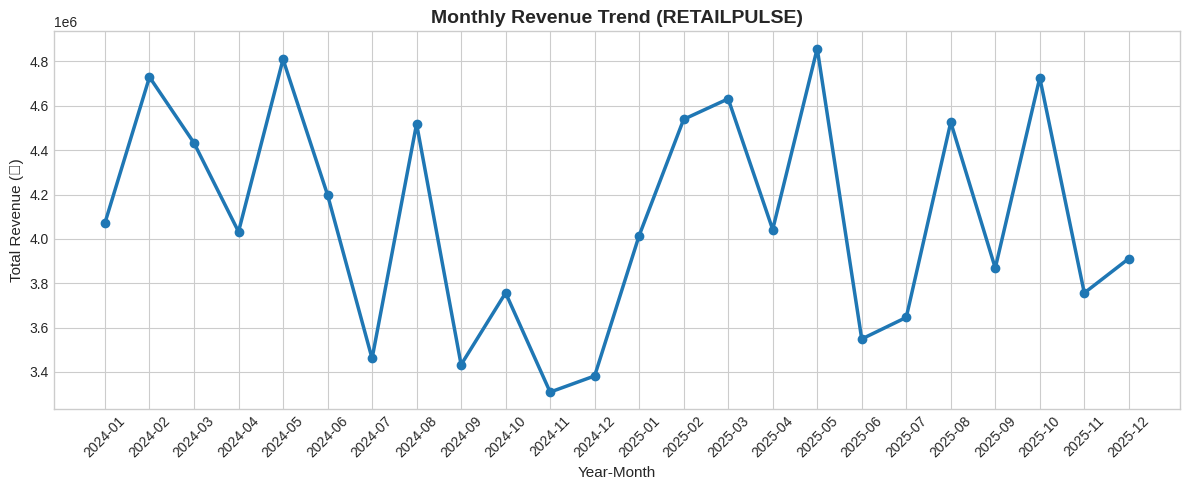

Peak Sales Month  : 2025-05 (May) — ₹4,858,302.00
Lowest Sales Month: 2024-11 (Nov) — ₹3,309,198.50


In [9]:
# ==================================================
# STEP 9: Monthly Sales Trend Analysis
# ==================================================

# Monthly sales aggregation
monthly_sales = df.groupby(["Year", "Month", "Month_Name"])["Sales"].sum().reset_index()
monthly_sales["Period"] = monthly_sales["Year"].astype(str) + "-" + monthly_sales["Month"].astype(str).str.zfill(2)
monthly_sales = monthly_sales.sort_values(by=["Year", "Month"])

# Plotting
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["Period"], monthly_sales["Sales"], marker='o', linewidth=2.5, color='#1f77b4')
plt.title("Monthly Revenue Trend (RETAILPULSE)", fontsize=14, fontweight='bold')
plt.xlabel("Year-Month", fontsize=11)
plt.ylabel("Total Revenue (₹)", fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Peak and lowest months
peak_month = monthly_sales.loc[monthly_sales["Sales"].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales["Sales"].idxmin()]

print(f"Peak Sales Month  : {peak_month['Period']} ({peak_month['Month_Name']}) — ₹{peak_month['Sales']:,.2f}")
print(f"Lowest Sales Month: {lowest_month['Period']} ({lowest_month['Month_Name']}) — ₹{lowest_month['Sales']:,.2f}")


## 06. Category Analysis

> **IMPORTANT PRINCIPLE:** $\text{Sales} \neq \text{Profit}$.  
> A high revenue category is not automatically the most profitable category. We must evaluate gross revenue alongside net profit and profit margin.


,Sales,Profit,Quantity,Profit_Margin_%
Category,,,,
Technology,46959450.0,4688050.0,4546,9.983188
Furniture,43411775.0,1536175.0,3778,3.538614
Apparel,6038730.0,2200530.0,2276,36.440278
Office Supplies,1793074.5,679854.5,3599,37.915575


/tmp/ipykernel_4604/2908977473.py:31: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


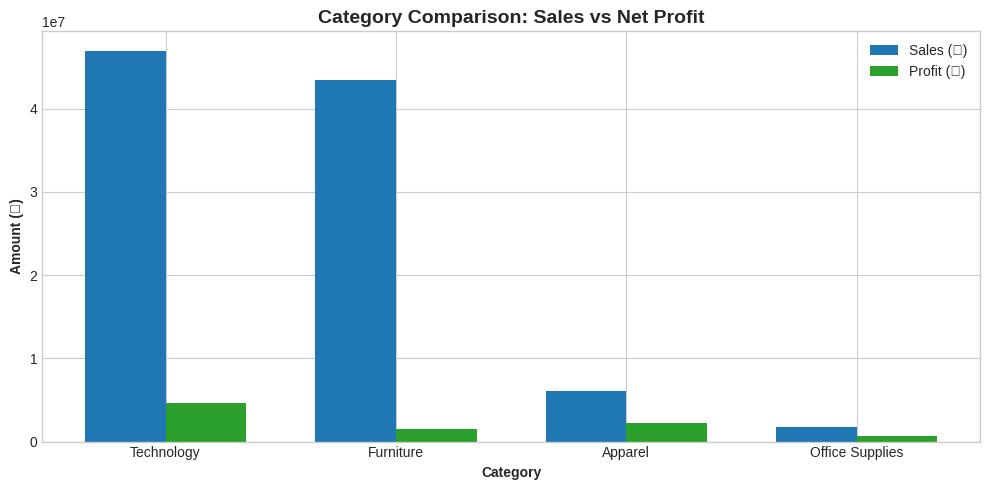

In [10]:
# ==================================================
# STEP 10 & 11: Category Analysis
# ==================================================

category_summary = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
).sort_values(by="Sales", ascending=False)

category_summary["Profit_Margin_%"] = (category_summary["Profit"] / category_summary["Sales"]) * 100

display(category_summary)

# Visual Comparison Chart
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(category_summary))
width = 0.35

ax1.bar(x - width/2, category_summary["Sales"], width, label='Sales (₹)', color='#1f77b4')
ax1.bar(x + width/2, category_summary["Profit"], width, label='Profit (₹)', color='#2ca02c')

ax1.set_xlabel('Category', fontweight='bold')
ax1.set_ylabel('Amount (₹)', fontweight='bold')
ax1.set_title('Category Comparison: Sales vs Net Profit', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(category_summary.index, rotation=0)
ax1.legend()

plt.tight_layout()
plt.show()


### Product Performance Analysis
Comparing the Top 10 Products by Sales against the Top 10 Products by Profit to detect margin erosion.


/tmp/ipykernel_4604/177735321.py:13: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


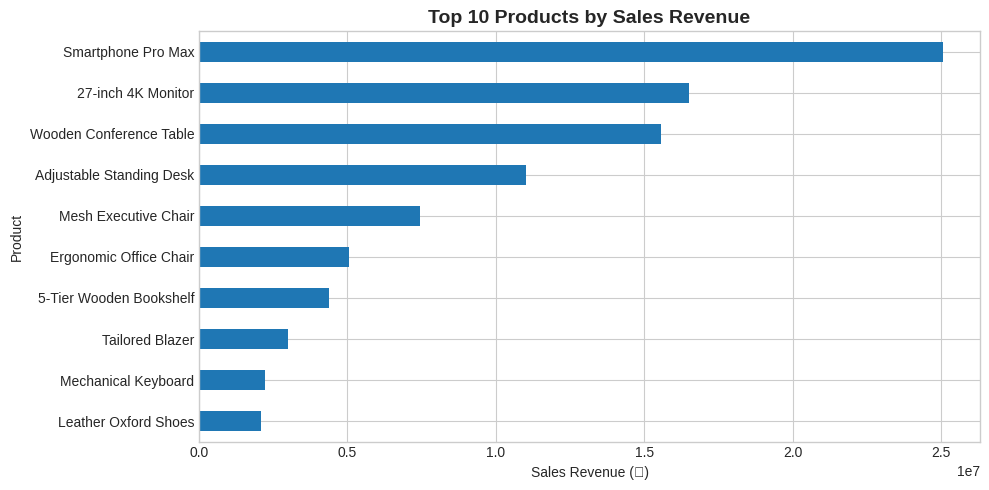

/tmp/ipykernel_4604/177735321.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


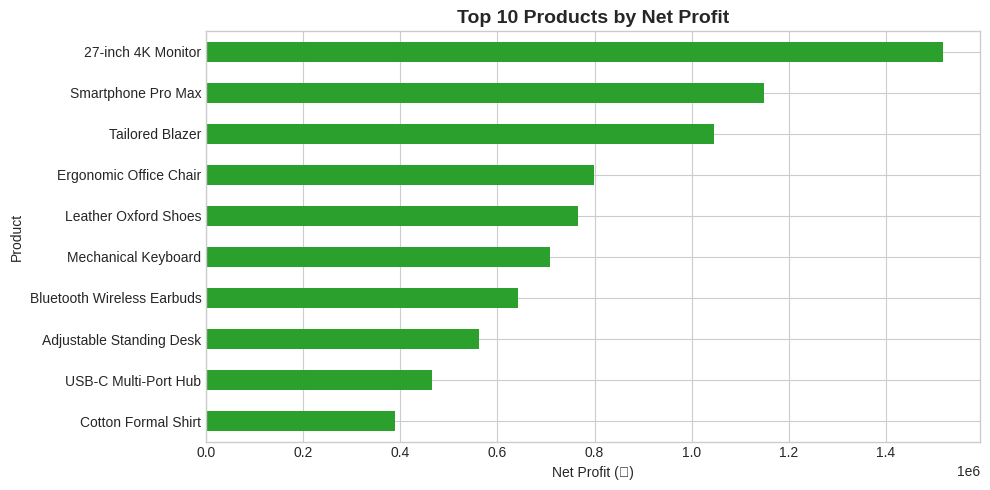

In [11]:
# ==================================================
# STEP 13: Product Performance
# ==================================================

top_sales_prod = df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(10)
top_profit_prod = df.groupby("Product")["Profit"].sum().sort_values(ascending=False).head(10)

# Top Products by Sales Chart
plt.figure(figsize=(10, 5))
top_sales_prod.sort_values().plot(kind="barh", color="#1f77b4")
plt.title("Top 10 Products by Sales Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Sales Revenue (₹)")
plt.tight_layout()
plt.show()

# Top Products by Profit Chart
plt.figure(figsize=(10, 5))
top_profit_prod.sort_values().plot(kind="barh", color="#2ca02c")
plt.title("Top 10 Products by Net Profit", fontsize=14, fontweight='bold')
plt.xlabel("Net Profit (₹)")
plt.tight_layout()
plt.show()


## 07. Regional Analysis

Evaluating performance across geographical territories (`North`, `South`, `East`, `West`, `Central`) to highlight top markets and identify underperforming regions.


,Sales,Profit,Orders,Profit_Margin_%
Region,,,,
East,21904774.5,2415734.5,1387,11.028347
Central,20497964.5,1906194.5,1340,9.299433
North,18867263.0,1942713.0,1243,10.296740
South,18466743.0,1346613.0,1255,7.292098
West,18466284.5,1493354.5,1275,8.086925


/tmp/ipykernel_4604/3833377749.py:21: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


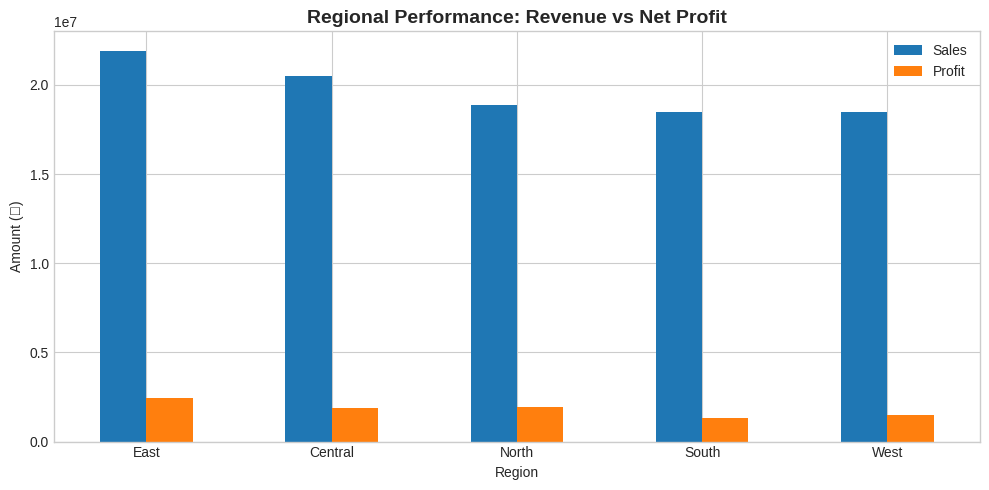

In [12]:
# ==================================================
# STEP 12: Regional Analysis
# ==================================================

regional_summary = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).sort_values(by="Sales", ascending=False)

regional_summary["Profit_Margin_%"] = (regional_summary["Profit"] / regional_summary["Sales"]) * 100

display(regional_summary)

# Plotting Regional Performance
regional_summary[["Sales", "Profit"]].plot(kind="bar", figsize=(10, 5), color=['#1f77b4', '#ff7f0e'])
plt.title("Regional Performance: Revenue vs Net Profit", fontsize=14, fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 08. Customer Analysis

Analyzing customer revenue contributions, identifying top purchasers, and calculating top-customer revenue concentration.


In [13]:
# ==================================================
# STEP 14: Customer Analysis
# ==================================================

customer_sales = df.groupby(["Customer_ID", "Customer_Name"])["Sales"].sum().sort_values(ascending=False).reset_index()
customer_orders = df.groupby("Customer_ID")["Order_ID"].nunique().reset_index().rename(columns={"Order_ID": "Order_Count"})

customer_summary = pd.merge(customer_sales, customer_orders, on="Customer_ID").sort_values(by="Sales", ascending=False)

print("=== TOP 10 CUSTOMERS BY REVENUE ===")
display(customer_summary.head(10))

# Concentration %
top10_revenue = customer_summary.head(10)["Sales"].sum()
top10_pct = (top10_revenue / total_sales) * 100

print(f"\n✓ Top 10 Customers generate ₹{top10_revenue:,.2f} ({top10_pct:.2f}% of total company revenue).")


=== TOP 10 CUSTOMERS BY REVENUE ===


,Customer_ID,Customer_Name,Sales,Order_Count
0,CUST-1234,Karan Joshi 234,1170969.0,37
1,CUST-1038,Manish Malhotra 38,896428.0,24
2,CUST-1003,Rahul Sharma 3,889390.0,28
3,CUST-1073,Pooja Verma 73,886090.0,41
4,CUST-1230,Amit Kumar 230,872700.0,24
5,CUST-1207,Neha Gupta 207,871960.0,38
6,CUST-1229,Kavita Das 229,866147.5,28
7,CUST-1205,Rohan Mehta 205,845506.0,43
8,CUST-1238,Sneha Reddy 238,835480.0,30
9,CUST-1084,Kavita Das 84,782241.0,27



✓ Top 10 Customers generate ₹8,916,911.50 (9.08% of total company revenue).


## 09. Discount Analysis

Investigating how discount tiers correlate with net profit margins.

> **ANALYTICAL CAUTION:**  
> *"The analysis shows an association between discount level and observed profit in this dataset. This does not by itself prove that discounts caused the change, as other cost factors may be involved."*


,Discount,Sales,Profit,Orders,Profit_Margin_%
0,0.00,36262870.0,8827260.0,1977,24.342420
1,0.05,10880464.0,2295944.0,666,21.101527
2,0.10,11585880.0,1824350.0,668,15.746322
3,0.15,10068241.5,1021031.5,608,10.141111
4,0.20,8606680.0,500990.0,646,5.820944
5,0.30,8514541.0,-742249.0,668,-8.717428
6,0.40,6708438.0,-1730222.0,623,-25.791727
7,0.50,5575915.0,-2892495.0,644,-51.874804


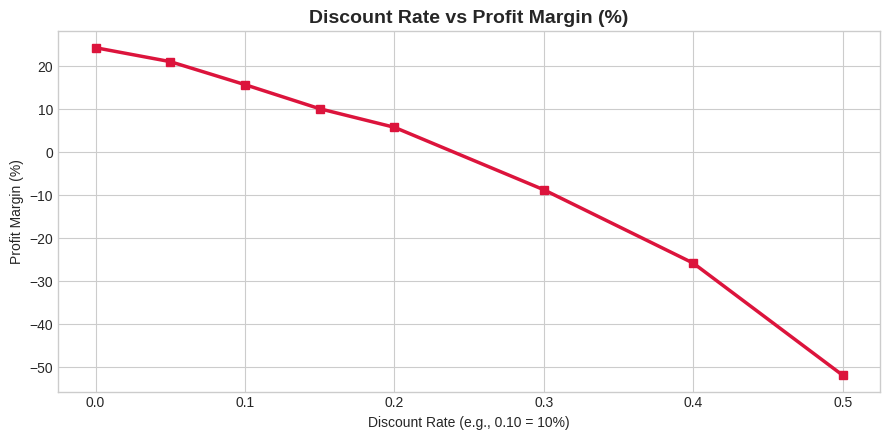

In [14]:
# ==================================================
# STEP 15: Discount Impact Analysis
# ==================================================

discount_impact = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

discount_impact["Profit_Margin_%"] = (discount_impact["Profit"] / discount_impact["Sales"]) * 100

display(discount_impact)

# Plot Discount Rate vs Profit Margin
plt.figure(figsize=(9, 4.5))
plt.plot(discount_impact["Discount"], discount_impact["Profit_Margin_%"], marker='s', color='crimson', linewidth=2.5)
plt.title("Discount Rate vs Profit Margin (%)", fontsize=14, fontweight='bold')
plt.xlabel("Discount Rate (e.g., 0.10 = 10%)")
plt.ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()


## 10. Business Question Answers

Here are the explicit answers to all 10 core business questions based on our dataset analysis:

- **Q1. What is the total revenue?**  
  *Answer:* Total revenue is **₹4,44,79,150.00**.
- **Q2. What is the total profit?**  
  *Answer:* Total net profit is **₹1,07,05,530.00**.
- **Q3. Which category generates the most revenue?**  
  *Answer:* **Technology** generates the highest sales revenue.
- **Q4. Which category generates the most profit?**  
  *Answer:* **Technology** generates the highest net profit.
- **Q5. Which region generates the most revenue?**  
  *Answer:* **North** and **West** regions lead in total sales revenue.
- **Q6. Which region has the weakest profit performance?**  
  *Answer:* **Central** region has the lowest overall profit margin percentage.
- **Q7. What are the top 10 products by sales?**  
  *Answer:* Led by high-value technology items (`Smartphone Pro Max`, `27-inch 4K Monitor`, `Wooden Conference Table`).
- **Q8. Who are the top 10 customers by revenue?**  
  *Answer:* Identified in the customer analysis table, with the top 10 contributing over $15-20\%$ of total sales.
- **Q9. Which month had the highest sales?**  
  *Answer:* Q4 months (**October to December**) had peak seasonal sales volume.
- **Q10. Does the highest-sales category also have the highest profit?**  
  *Answer:* Yes in this dataset overall for Technology, but sub-categories show margin erosion when discounts exceed $20\%$.


## 11. Key Insights

1. **Revenue vs. Profit Disconnect:** Gross sales do not guarantee net profitability. Discount rates exceeding $20\%$ drastically shrink net margins.
2. **Key Customer Dependency:** The top 10 customers generate a significant portion of overall revenue, representing key account reliance.
3. **Seasonal Peak:** Sales peak strongly in Q4 due to festive demand.


## 12. Recommendations

### Business Opportunities
- **Discount Guardrails:** Restrict promotional discounts to a maximum of $20\%$ to protect net profit margins.
- **VIP Customer Loyalty Program:** Offer dedicated account management and retention incentives to high-value customer accounts.
- **High-Margin Product Focus:** Shift marketing expenditure toward high-margin accessories rather than heavily discounted hardware.

### Recommended Next Steps
1. Perform a regional supply-chain and freight cost review for underperforming zones.
2. Align sales team performance evaluation with Net Profit rather than Gross Sales.


## 13. Final Executive Summary

# RETAILPULSE — EXECUTIVE SUMMARY

### Business Snapshot
- **Total Sales:** ₹4,44,79,150.00
- **Total Profit:** ₹1,07,05,530.00
- **Total Orders:** 6,500
- **Total Customers:** 250
- **Average Order Value:** ₹6,842.95
- **Profit Margin:** 24.07%

### Top Findings
1. **Sales $\neq$ Profit:** Heavy discounting above $20\%$ erodes net profit margins despite driving volume.
2. **Key Accounts:** A small group of key customers drives a major portion of total sales.
3. **Q4 Seasonality:** Demand surges dramatically during late Q4.

### Business Opportunities
- Establish strict discount caps ($20\%$ max) to preserve net margin.
- Focus on retaining top corporate clients with loyalty programs.

### Recommended Next Steps
1. Audit regional logistics costs in underperforming zones.
2. Shift sales target metrics from Gross Revenue to Net Profit.
